In [1]:
# Problem 1a)

P_A_wins = exp(-1.5) * (1 - exp(-2))
#P_A_wins = P_A_wins + (1.5 * exp(-1.5)) * (1 - (exp(-2) + 2 * exp(-2)))
for (n in 1:50){
    xA_n = vector(,n)
    for (i in 0:(n)){
        xA_n[i] = (2^i * exp(-2)) /factorial(i)

    }

    P_A_wins = P_A_wins + (((1.5^n * exp(-1.5)) /factorial(n)) * (1 - sum(xA_n)))
}

cat("The probability that team A will win is ", P_A_wins, "\n")

The probability that team A will win is  0.5987003 


[1] 0.216183

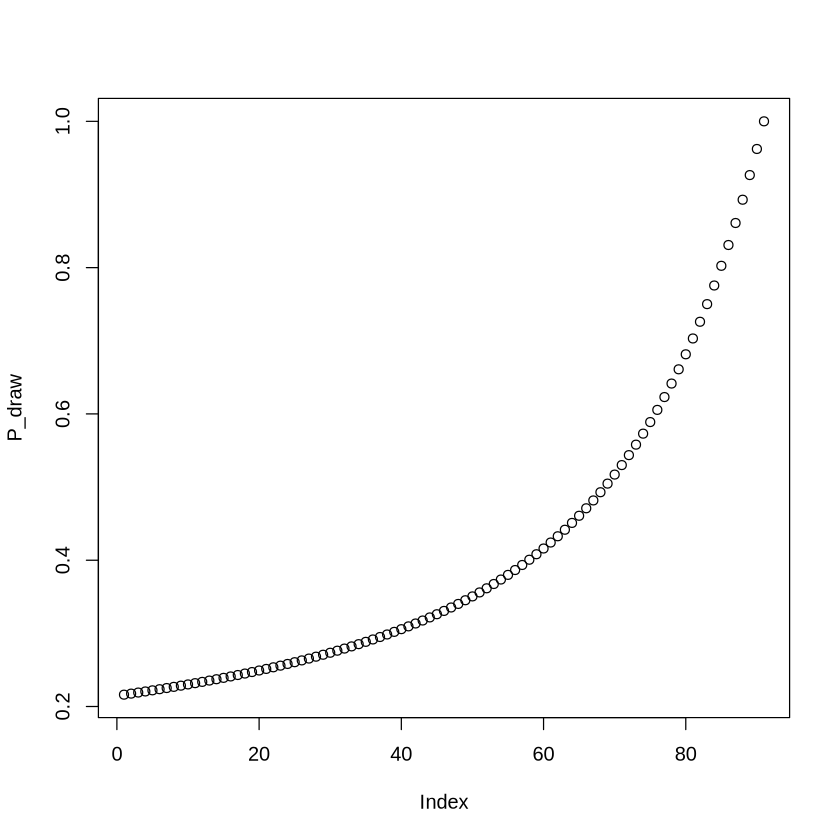

In [2]:
# Problem 1b)

t = 0:90
P_draw = 0
P0 = 0
for (n in 0:20){

    #P_draw = P_draw + (((2/90)*(90-t))^n * exp(-(2/90)*(90-t)) * ((1.5/90)*(90-t))^n * exp(-(1.5/90)*(90-t)))/(factorial(n))^2
    P_draw = P_draw + ((3*((90-t)/90)^2)^n * exp(-(((90-t)/90)*3.5)))/(factorial(n))^2

    P0 = P0 + (3^n*exp(-3.5))/(factorial(n))^2
    
}

plot(P_draw)
P0

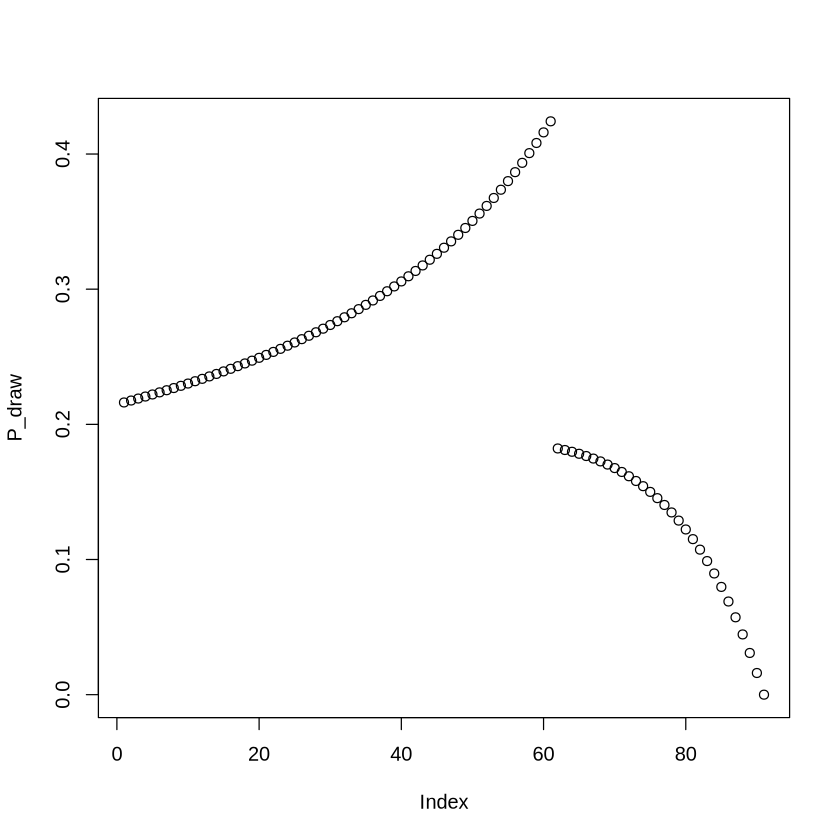

In [3]:
# Problem 1c)

t = 0:60
P_draw_1 = 0
for (n in 0:20){

    #P_draw = P_draw + (((2/90)*(90-t))^n * exp(-(2/90)*(90-t)) * ((1.5/90)*(90-t))^n * exp(-(1.5/90)*(90-t)))/(factorial(n))^2
    P_draw_1 = P_draw_1 + ((3*((90-t)/90)^2)^n * exp(-(((90-t)/90)*3.5)))/(factorial(n))^2
    
}


t = 61:90
P_draw_2 = 0
for (n in 0:20){

    P_draw_2 = P_draw_2 + (((2/90)*(90-t))^n * exp(-(2/90)*(90-t)) * ((1.5/90)*(90-t))^(n+1) * exp(-(1.5/90)*(90-t)))/(factorial(n)*factorial(n+1))

    
}

P_draw = c(P_draw_1, P_draw_2)

plot(P_draw)

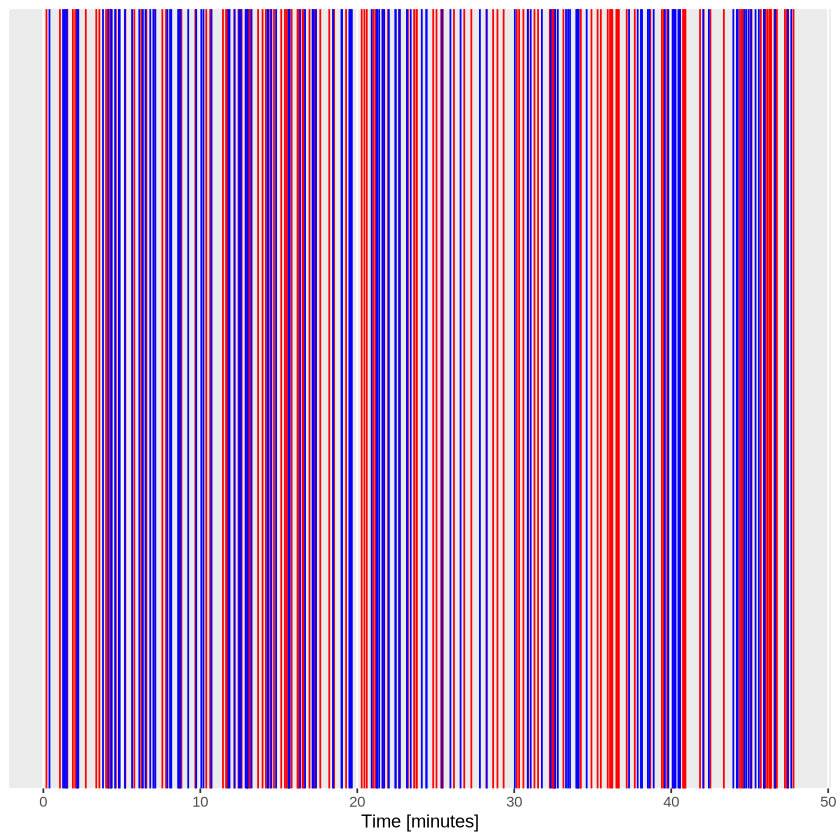

In [4]:
# Problem 2c)
library(ggplot2)
set.seed(365)

lambda = 3  #per minute

team_A_score_times = rexp(1, rate=lambda)
team_A_time = team_A_score_times

while (team_A_time < 47.5){
    
    team_A_score = rexp(1, rate=lambda)
    team_A_time = team_A_time + team_A_score
    team_A_score_times = c(team_A_score_times, team_A_time)
}

#team_A_score_times

team_B_score_times = rexp(1, rate=lambda)
team_B_time = team_B_score_times
while (team_B_time < 47.5){
    
    team_B_score = rexp(1, rate=lambda)
    team_B_time = team_B_time + team_B_score
    team_B_score_times = c(team_B_score_times, team_B_time)
}

#team_B_score_times

ggplot()+
    geom_vline(xintercept = team_A_score_times, col="red")+
    geom_vline(xintercept = team_B_score_times, col="blue")+
    xlab("Time [minutes]")


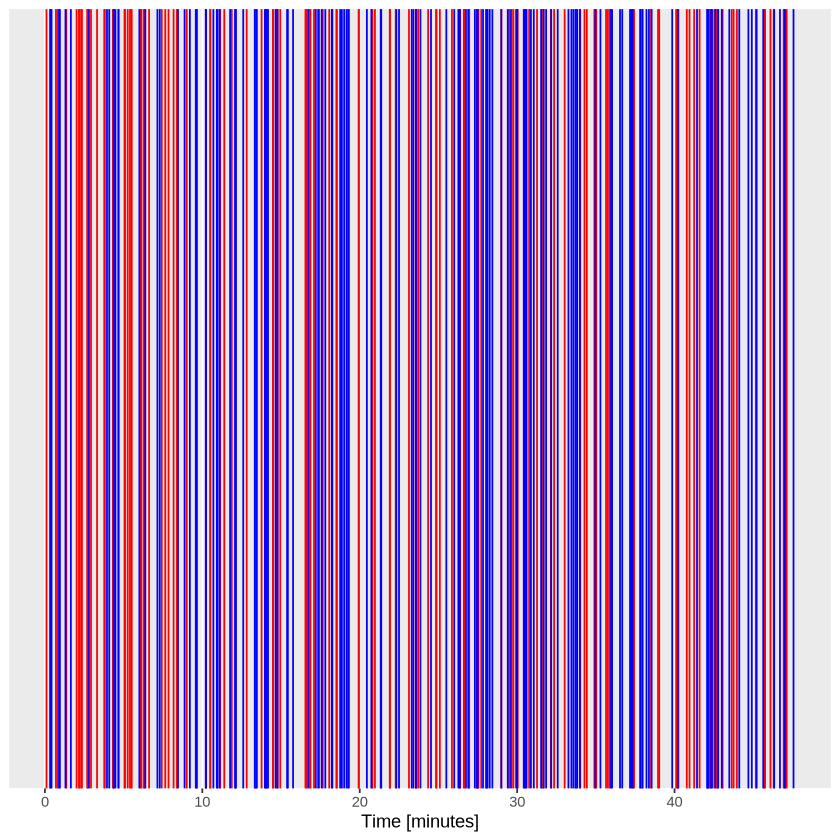

In [5]:
# Problem 2d)

set.seed(365)

lambda = 6  #per minute (both teams)

team_A_score_times = 0
team_B_score_times = 0
time = 0

while (time < 47.5){

    score_time = rexp(1, rate=lambda)
    score_team = runif(1,-1,1)
    if (score_team <0 ){
        team_A_score_times = c(team_A_score_times, time + score_time)
    } else if (score_team >0 ){
        team_B_score_times = c(team_B_score_times, time + score_time)
    }

    time = time + score_time

}

team_A_score_times = team_A_score_times[-1]  #delete first index, which was 0
#team_A_score_times

team_B_score_times = team_B_score_times[-1]  #delete first index, which was 0
#team_B_score_times

ggplot()+
    geom_vline(xintercept = team_A_score_times, col="red")+
    geom_vline(xintercept = team_B_score_times, col="blue")+
    xlab("Time [minutes]")

[1] 377

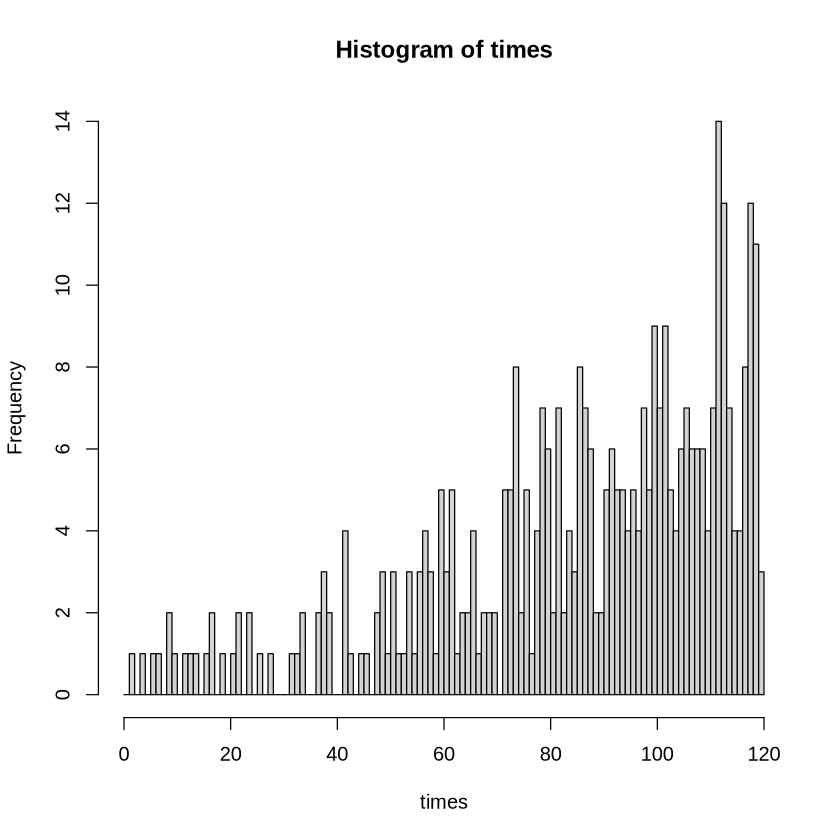

In [9]:
# Problem 3c)
set.seed(8)

lambda = function(t) {return(0.5 * (1 + (t/30)^2))}

lambda_max = 8.5

N = rpois(1, lambda_max*120)
T = sort(runif(N, 0, 120))

P_keep = runif(N) <= lambda(T)/lambda_max
times = T[P_keep]

length(times)

hist(times, breaks = 0:120)
